In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
from logic.database import AA_PROPERTIES, AA_CLASS, ALPHA, BETA, GAMMA
from extra.onelettercodes import aa_codes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

### **Create dataframe with amino acids and their properties**

In [3]:
amino_acids = list(AA_PROPERTIES.keys())

df = pd.DataFrame({
    'volume': [AA_PROPERTIES[aa]['volume'] for aa in amino_acids],
    'hydrophobicity': [AA_PROPERTIES[aa]['hydrophobicity'] for aa in amino_acids],
    'charge': [AA_PROPERTIES[aa]['charge'] for aa in amino_acids],
}, index=amino_acids)

df_weighted = pd.DataFrame({
    'volume':        80 * df['volume'],
    'charge':        20  * df['charge'],
    'hydrophobicity': 15 * df['hydrophobicity'],
}, index=amino_acids)

### **Scale values in the dataframe, so that a unit change in each one represents the same thing**

In [4]:

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)
df_scaled = pd.DataFrame(X_scaled, index=amino_acids, columns=df.columns)


In [8]:
X_weighted = np.column_stack([
    ALPHA * df['volume'].values,        # 80 * volume
    BETA  * df['charge'].values,        # 20 * charge
    GAMMA * df['hydrophobicity'].values # 15 * hydrophobicity
])

### **PCA, looking at top 2 components**

In [9]:

pca = PCA(n_components=2)
coords = pca.fit_transform(X_weighted)  # shape (20, 2)


### **Preliminary dictionaries defining amino acid properties, and color mappings for use later**

In [10]:
AA_VOLUME_CLASS = {
    'G': 'very_small', 'A': 'very_small', 'S': 'very_small',
    'T': 'small', 'C': 'small', 'P': 'small', 'D': 'small', 'N': 'small',
    'V': 'medium', 'H': 'medium', 'E': 'medium', 'Q': 'medium',
    'I': 'large', 'L': 'large', 'M': 'large', 'K': 'large', 'R': 'large',
    'F': 'very_large', 'W': 'very_large', 'Y': 'very_large',
}

VOLUME_COLORS = {
    'very_small': '#264653',
    'small':      '#2a9d8f',
    'medium':     '#e9c46a',
    'large':      '#e76f51',
    'very_large': '#1d3557',
}


CLASS_COLORS = {
    'positive': '#e63946',
    'negative': '#457b9d',
    'polar':    '#2a9d8f',
    'nonpolar': '#e9c46a',
}


### **Plotting of results when PCA was run, with each plot colored for different simulation parameters**

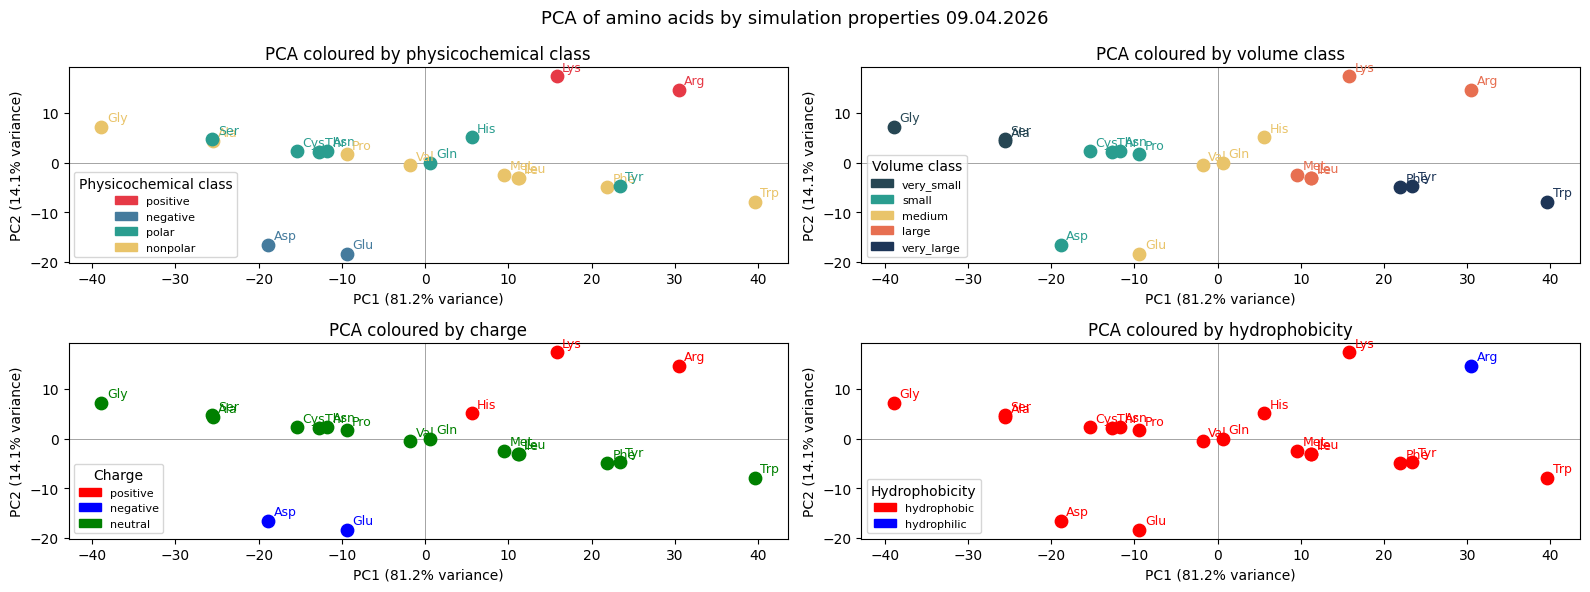

In [11]:


_CHARGE_COLOR = {'positive': 'red', 'negative': 'blue', 'neutral': 'green'}
_charge_map = {aa: 'red' if AA_PROPERTIES[aa]['charge'] > 0 else 'blue' if AA_PROPERTIES[aa]['charge'] < 0 else 'green' for aa in amino_acids}
_charge_legend = {lbl: col for lbl, col in _CHARGE_COLOR.items() if col in _charge_map.values()}

fig, axes = plt.subplots(2, 2, figsize=(16, 6))
axes = axes.flatten()

for ax, color_map, title, label in [
    (axes[0], {aa: CLASS_COLORS[AA_CLASS[aa]]  for aa in amino_acids}, 'Physicochemical class', CLASS_COLORS),
    (axes[1], {aa: VOLUME_COLORS[AA_VOLUME_CLASS[aa]] for aa in amino_acids}, 'Volume class',          VOLUME_COLORS),
    (axes[2], _charge_map, 'Charge', _charge_legend),
    (axes[3], {aa: 'red' if df_weighted.loc[aa, 'hydrophobicity'] > 0 else 'blue' for aa in amino_acids}, 'Hydrophobicity', {'hydrophobic': 'red', 'hydrophilic': 'blue'}),
]:
    for i, aa in enumerate(amino_acids):
        c = color_map[aa]
        ax.scatter(coords[i, 0], coords[i, 1], color=c, s=80, zorder=3)
        ax.annotate(aa_codes[aa], (coords[i, 0], coords[i, 1]), fontsize=9, color=c,
                    xytext=(4, 4), textcoords='offset points')

    handles = [mpatches.Patch(color=col, label=lbl) for lbl, col in label.items()]
    ax.legend(handles=handles, title=title, fontsize=8)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    ax.set_title(f'PCA coloured by {title.lower()}')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

plt.suptitle('PCA of amino acids by simulation properties 09.04.2026', fontsize=13)
plt.tight_layout()
plt.show()



      volume  charge  hydrophobicity       score
G   0.000000     0.0        6.833333  113.166667
A  13.664350     0.0       10.500000   95.835650
S  13.584906     0.0        6.166667  100.248428
T  26.693148     0.0        6.333333   86.973519
C  23.992056     0.0       11.666667   84.341278
N  27.646475     0.0        1.666667   90.686859
D  24.309831   -20.0        1.666667  114.023502
E  33.922542   -20.0        1.666667  104.410791
Q  40.278054     0.0        1.666667   78.055280
V  37.815293     0.0       14.500000   67.684707
L  51.082423     0.0       13.833333   55.084244
I  51.082423     0.0       15.000000   53.917577
P  30.029791     0.0        4.833333   85.136875
M  49.334657     0.0       10.666667   59.998676
H  44.170804     6.0        2.166667   67.662529
K  51.876862    20.0        1.000000   47.123138
R  66.812314    20.0        0.000000   33.187686
F  61.966236     0.0       12.166667   45.867097
Y  63.475670     0.0        5.333333   51.190996
W  80.000000     0.0

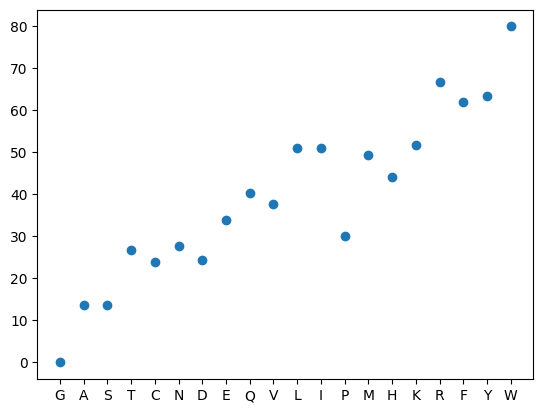

In [12]:
print(df_weighted)
plt.scatter(amino_acids[0:], df_weighted['volume'])

In [13]:

ALPHA           = 80   # pA — how much volume affects current (bigger AA = more blockage) #used to be 20, changed alpha and beta so that peptide has a larger effect on the current
BETA            = 20   # pA — how much charge affects current per unit charge #used to be 5
GAMMA          = 15   # pA — how much hydrophobicity affects current per unit (0-1) hydrophobicity
pep_baseline = 0.5
IOS=240
weighted_volume         =  df_weighted['volume']
weighted_charge         =  df_weighted['charge']
weighted_hydrophobicity =  df_weighted['hydrophobicity']


df_weighted['score'] = (pep_baseline*IOS
            - weighted_volume
            - weighted_charge
            - weighted_hydrophobicity)



In [14]:
df_weighted

,volume,charge,hydrophobicity,score
G,0.000000,0.0,6.833333,113.166667
A,13.664350,0.0,10.500000,95.835650
S,13.584906,0.0,6.166667,100.248428
T,26.693148,0.0,6.333333,86.973519
C,23.992056,0.0,11.666667,84.341278
N,27.646475,0.0,1.666667,90.686859
D,24.309831,-20.0,1.666667,114.023502
E,33.922542,-20.0,1.666667,104.410791
Q,40.278054,0.0,1.666667,78.055280
V,37.815293,0.0,14.500000,67.684707


In [7]:
X = df_weighted[['volume', 'weighted_charge', 'weighted_hydrophobicity']].values

KeyError: "['weighted_charge', 'weighted_hydrophobicity'] not in index"

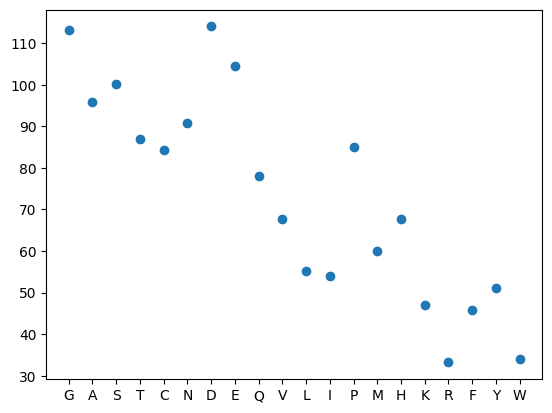

In [15]:
plt.scatter(df_weighted.index, df_weighted['score'])

In [11]:
df_sorted=df_weighted.sort_values(['score'], ascending = False)

In [12]:
weighted_vol = 

SyntaxError: invalid syntax (2324847545.py, line 1)

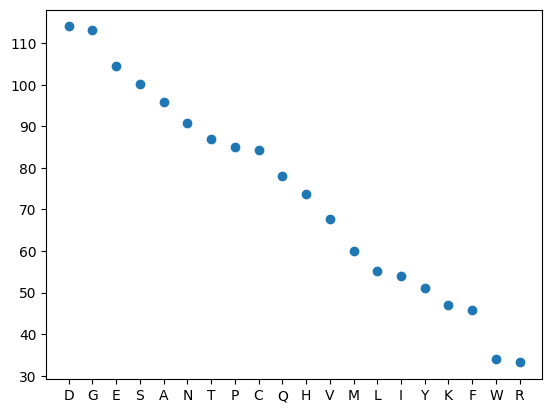

In [13]:
plt.scatter(df_sorted.index, df_sorted['score'])

In [14]:
# 4 clusters. 5 elements. 4^5

# 1024 permutations. 1024 values.

# 5 clusters. 5 elements. 5^5

# all windows values. cluster


In [15]:
5**5

3125

In [16]:
5**7

78125

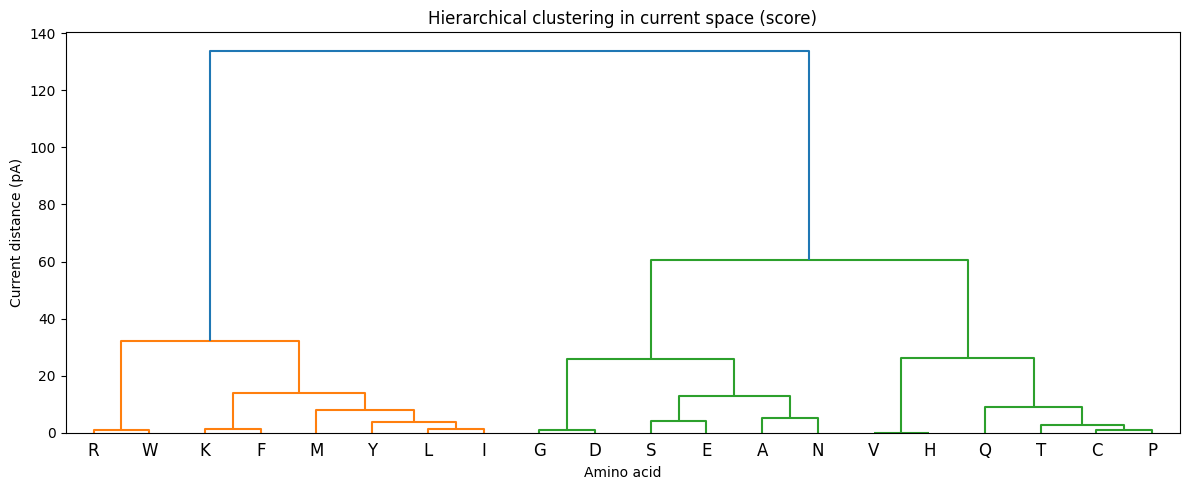

  AA  cluster       score
R  R        1   33.187686
W  W        1   34.000000
F  F        2   45.867097
K  K        2   47.123138
Y  Y        3   51.190996
I  I        3   53.917577
L  L        3   55.084244
M  M        3   59.998676
H  H        6   67.662529
V  V        6   67.684707
Q  Q        7   78.055280
C  C        7   84.341278
P  P        7   85.136875
T  T        7   86.973519
N  N        5   90.686859
A  A        5   95.835650
S  S        5  100.248428
E  E        5  104.410791
G  G        4  113.166667
D  D        4  114.023502


In [32]:
# Cluster in current (score) space
X_current = df_weighted['score'].values.reshape(-1, 1)

linkage_matrix_current = linkage(X_current, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(linkage_matrix_current, labels=amino_acids, ax=ax)
ax.set_title('Hierarchical clustering in current space (score)')
ax.set_xlabel('Amino acid')
ax.set_ylabel('Current distance (pA)')
plt.tight_layout()
plt.show()

n_clusters = 7
labels_current = fcluster(linkage_matrix_current, n_clusters, criterion='maxclust')
cluster_df_current = pd.DataFrame({'AA': amino_acids, 'cluster': labels_current, 'score': df_weighted['score']})
cluster_df_current = cluster_df_current.sort_values('score')
print(cluster_df_current)

In [33]:
labels = fcluster(linkage_matrix_current, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({'AA': amino_acids, 'cluster': labels})
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")

Cluster 1: ['R', 'W']
Cluster 2: ['K', 'F']
Cluster 3: ['L', 'I', 'M', 'Y']
Cluster 4: ['G', 'D']
Cluster 5: ['A', 'S', 'N', 'E']
Cluster 6: ['V', 'H']
Cluster 7: ['T', 'C', 'Q', 'P']


In [34]:
for c in sorted(cluster_df_current['cluster'].unique()):
    members = cluster_df_current[cluster_df_current['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")

Cluster 1: ['R', 'W']
R: class=positive, volume_class=large
W: class=nonpolar, volume_class=very_large
Cluster 1 classes: ['positive', 'nonpolar']
Cluster 1 volume classes: ['large', 'very_large']
----------------------------------------------------------------
Cluster 2: ['F', 'K']
F: class=nonpolar, volume_class=very_large
K: class=positive, volume_class=large
Cluster 2 classes: ['nonpolar', 'positive']
Cluster 2 volume classes: ['very_large', 'large']
----------------------------------------------------------------
Cluster 3: ['Y', 'I', 'L', 'M']
Y: class=polar, volume_class=very_large
I: class=nonpolar, volume_class=large
L: class=nonpolar, volume_class=large
M: class=nonpolar, volume_class=large
Cluster 3 classes: ['polar', 'nonpolar', 'nonpolar', 'nonpolar']
Cluster 3 volume classes: ['very_large', 'large', 'large', 'large']
----------------------------------------------------------------
Cluster 4: ['G', 'D']
G: class=nonpolar, volume_class=very_small
D: class=negative, volume_c

# **4 Clusters Results**


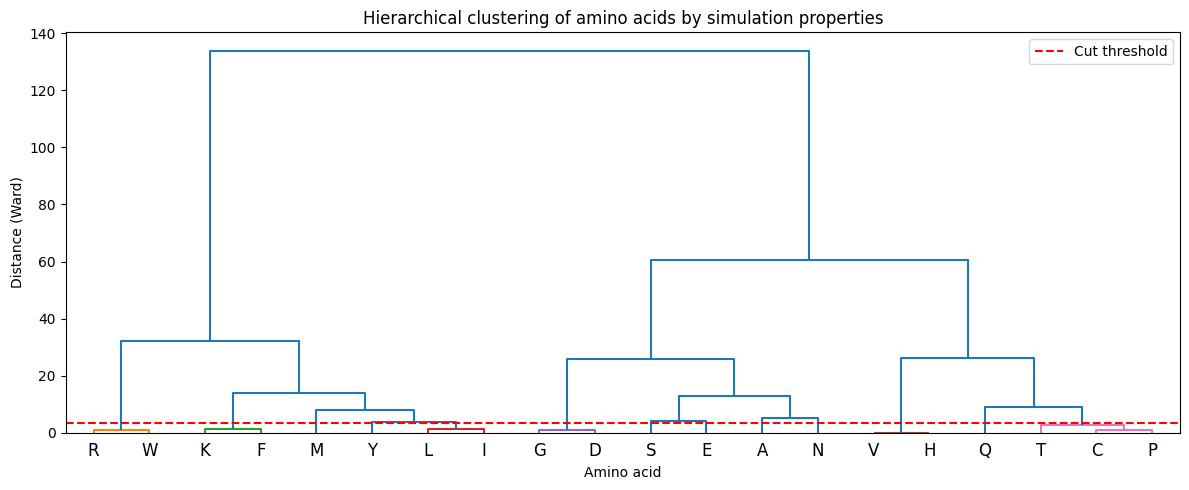

Cluster 1: ['R', 'W']
Cluster 2: ['L', 'I', 'M', 'K', 'F', 'Y']
Cluster 3: ['G', 'A', 'S', 'N', 'D', 'E']
Cluster 4: ['T', 'C', 'Q', 'V', 'P', 'H']


In [18]:
# 'ward' minimizes variance within clusters — good default
linkage_matrix = linkage(X_current, method='ward')

# --- 4. Plot dendrogram ---
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=amino_acids,
    ax=ax,
    color_threshold=3.5  # adjust this to change where clusters are cut
)
ax.set_title('Hierarchical clustering of amino acids by simulation properties')
ax.set_xlabel('Amino acid')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=3.5, color='red', linestyle='--', label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

# --- 5. Extract flat clusters ---
n_clusters = 4  # start with 4 to compare against your physicochemical scheme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({'AA': amino_acids, 'cluster': labels})
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")

In [19]:
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")


Cluster 1: ['R', 'W']
R: class=positive, volume_class=large
W: class=nonpolar, volume_class=very_large
Cluster 1 classes: ['positive', 'nonpolar']
Cluster 1 volume classes: ['large', 'very_large']
----------------------------------------------------------------
Cluster 2: ['L', 'I', 'M', 'K', 'F', 'Y']
L: class=nonpolar, volume_class=large
I: class=nonpolar, volume_class=large
M: class=nonpolar, volume_class=large
K: class=positive, volume_class=large
F: class=nonpolar, volume_class=very_large
Y: class=polar, volume_class=very_large
Cluster 2 classes: ['nonpolar', 'nonpolar', 'nonpolar', 'positive', 'nonpolar', 'polar']
Cluster 2 volume classes: ['large', 'large', 'large', 'large', 'very_large', 'very_large']
----------------------------------------------------------------
Cluster 3: ['G', 'A', 'S', 'N', 'D', 'E']
G: class=nonpolar, volume_class=very_small
A: class=nonpolar, volume_class=very_small
S: class=polar, volume_class=very_small
N: class=polar, volume_class=small
D: class=nega

In [20]:
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")


Cluster 1: ['R', 'W']
R: class=positive, volume_class=large
W: class=nonpolar, volume_class=very_large
Cluster 1 classes: ['positive', 'nonpolar']
Cluster 1 volume classes: ['large', 'very_large']
----------------------------------------------------------------
Cluster 2: ['L', 'I', 'M', 'K', 'F', 'Y']
L: class=nonpolar, volume_class=large
I: class=nonpolar, volume_class=large
M: class=nonpolar, volume_class=large
K: class=positive, volume_class=large
F: class=nonpolar, volume_class=very_large
Y: class=polar, volume_class=very_large
Cluster 2 classes: ['nonpolar', 'nonpolar', 'nonpolar', 'positive', 'nonpolar', 'polar']
Cluster 2 volume classes: ['large', 'large', 'large', 'large', 'very_large', 'very_large']
----------------------------------------------------------------
Cluster 3: ['G', 'A', 'S', 'N', 'D', 'E']
G: class=nonpolar, volume_class=very_small
A: class=nonpolar, volume_class=very_small
S: class=polar, volume_class=very_small
N: class=polar, volume_class=small
D: class=nega

# More cluster Experimentation

In [1]:
# 'ward' minimizes variance within clusters — good default
linkage_matrix = linkage(X_current, method='ward')

# --- 4. Plot dendrogram ---
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=amino_acids,
    ax=ax,
    color_threshold=3.5  # adjust this to change where clusters are cut
)
ax.set_title('Hierarchical clustering of amino acids by simulation properties')
ax.set_xlabel('Amino acid')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=3.5, color='red', linestyle='--', label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

# --- 5. Extract flat clusters ---
n_clusters = 5  # start with 4 to compare against your physicochemical scheme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({'AA': amino_acids, 'cluster': labels})
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")

NameError: name 'linkage' is not defined

In [21]:
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")


Cluster 1: ['D', 'E']
D: class=negative, volume_class=small
E: class=negative, volume_class=medium
Cluster 1 classes: ['negative', 'negative']
Cluster 1 volume classes: ['small', 'medium']
----------------------------------------------------------------
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
T: class=polar, volume_class=small
N: class=polar, volume_class=small
Q: class=polar, volume_class=medium
P: class=nonpolar, volume_class=small
H: class=polar, volume_class=medium
Cluster 2 classes: ['polar', 'polar', 'polar', 'nonpolar', 'polar']
Cluster 2 volume classes: ['small', 'small', 'medium', 'small', 'medium']
----------------------------------------------------------------
Cluster 3: ['G', 'A', 'S', 'C']
G: class=nonpolar, volume_class=very_small
A: class=nonpolar, volume_class=very_small
S: class=polar, volume_class=very_small
C: class=polar, volume_class=small
Cluster 3 classes: ['nonpolar', 'nonpolar', 'polar', 'polar']
Cluster 3 volume classes: ['very_small', 'very_small', 'very_small'

In [11]:
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")


Cluster 1: ['D', 'E']
D: class=negative, volume_class=small
E: class=negative, volume_class=medium
Cluster 1 classes: ['negative', 'negative']
Cluster 1 volume classes: ['small', 'medium']
----------------------------------------------------------------
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
T: class=polar, volume_class=small
N: class=polar, volume_class=small
Q: class=polar, volume_class=medium
P: class=nonpolar, volume_class=small
H: class=polar, volume_class=medium
Cluster 2 classes: ['polar', 'polar', 'polar', 'nonpolar', 'polar']
Cluster 2 volume classes: ['small', 'small', 'medium', 'small', 'medium']
----------------------------------------------------------------
Cluster 3: ['G', 'A', 'S', 'C']
G: class=nonpolar, volume_class=very_small
A: class=nonpolar, volume_class=very_small
S: class=polar, volume_class=very_small
C: class=polar, volume_class=small
Cluster 3 classes: ['nonpolar', 'nonpolar', 'polar', 'polar']
Cluster 3 volume classes: ['very_small', 'very_small', 'very_small'

In [ ]:
CLUSTER_5_COLORS = {
    '1, negative': 'blue',
    '2, polar and small': 'orange',
    '3, small': 'green',
    '4, positive': 'red',
    '5, large and nonpolar(with one polar)': 'purple'
}

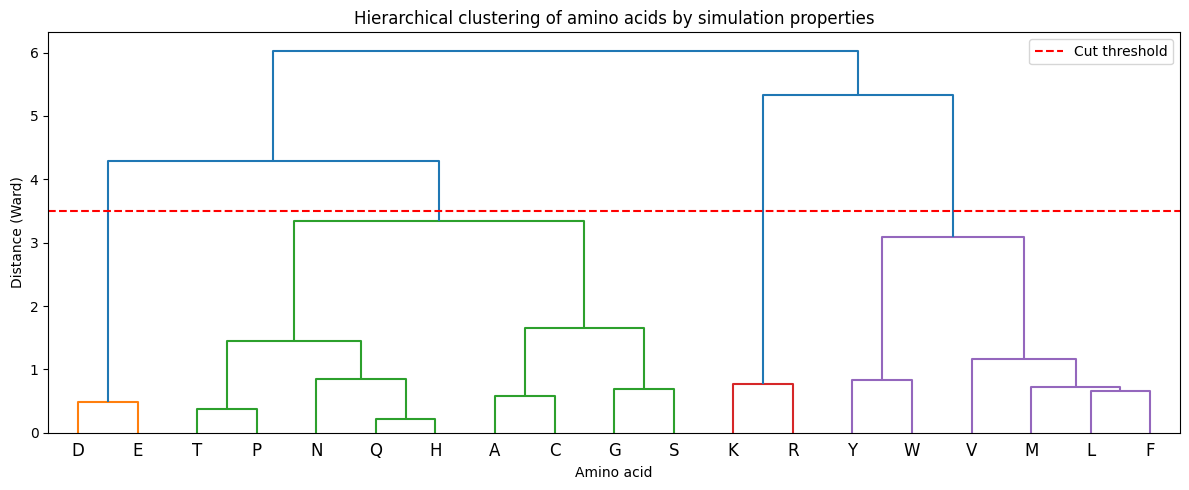

Cluster 1: ['D', 'E']
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
Cluster 3: ['G', 'A', 'S', 'C']
Cluster 4: ['K', 'R']
Cluster 5: ['Y', 'W']
Cluster 6: ['V', 'L', 'M', 'F']


In [22]:
# 'ward' minimizes variance within clusters — good default
linkage_matrix = linkage(X_scaled, method='ward')

# --- 4. Plot dendrogram ---
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=amino_acids,
    ax=ax,
    color_threshold=3.5  # adjust this to change where clusters are cut
)
ax.set_title('Hierarchical clustering of amino acids by simulation properties')
ax.set_xlabel('Amino acid')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=3.5, color='red', linestyle='--', label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

# --- 5. Extract flat clusters ---
n_clusters = 6  # start with 4 to compare against your physicochemical scheme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({'AA': amino_acids, 'cluster': labels})
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")

In [23]:
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")


Cluster 1: ['D', 'E']
D: class=negative, volume_class=small
E: class=negative, volume_class=medium
Cluster 1 classes: ['negative', 'negative']
Cluster 1 volume classes: ['small', 'medium']
----------------------------------------------------------------
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
T: class=polar, volume_class=small
N: class=polar, volume_class=small
Q: class=polar, volume_class=medium
P: class=nonpolar, volume_class=small
H: class=polar, volume_class=medium
Cluster 2 classes: ['polar', 'polar', 'polar', 'nonpolar', 'polar']
Cluster 2 volume classes: ['small', 'small', 'medium', 'small', 'medium']
----------------------------------------------------------------
Cluster 3: ['G', 'A', 'S', 'C']
G: class=nonpolar, volume_class=very_small
A: class=nonpolar, volume_class=very_small
S: class=polar, volume_class=very_small
C: class=polar, volume_class=small
Cluster 3 classes: ['nonpolar', 'nonpolar', 'polar', 'polar']
Cluster 3 volume classes: ['very_small', 'very_small', 'very_small'

In [ ]:
CLUSTER_6_COLORS = {
    '1, negative': 'blue',
    '2, polar and small(one NP)': 'orange',
    '3, verysmall-small': 'green',
    '4, positive': 'red',
    '5, very large': 'purple',
    '6, nonpolar': 'brown'
}

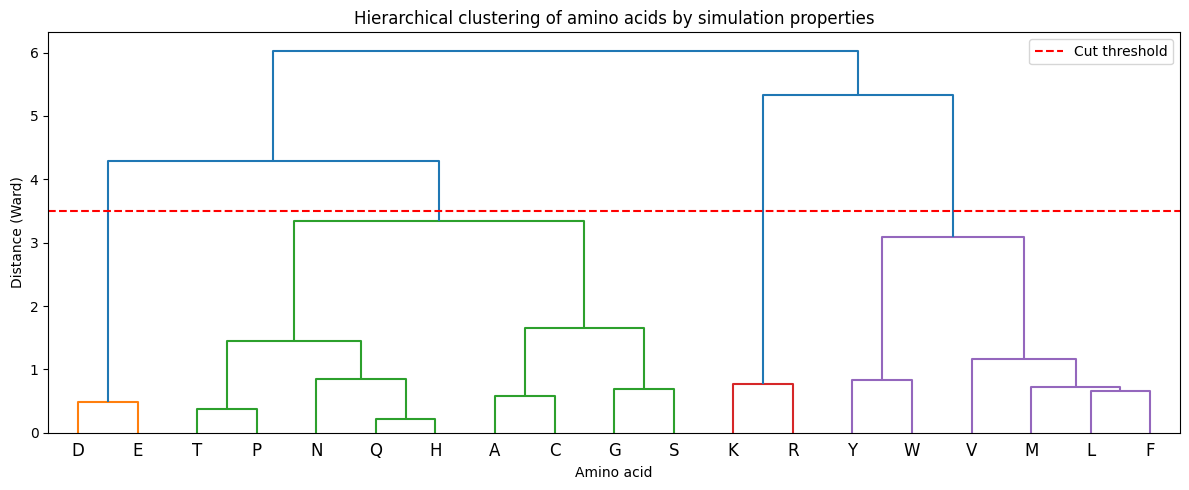

Cluster 1: ['D', 'E']
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
Cluster 3: ['A', 'C']
Cluster 4: ['G', 'S']
Cluster 5: ['K', 'R']
Cluster 6: ['Y', 'W']
Cluster 7: ['V', 'L', 'M', 'F']


In [24]:
# 'ward' minimizes variance within clusters — good default
linkage_matrix = linkage(X_scaled, method='ward')

# --- 4. Plot dendrogram ---
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=amino_acids,
    ax=ax,
    color_threshold=3.5  # adjust this to change where clusters are cut
)
ax.set_title('Hierarchical clustering of amino acids by simulation properties')
ax.set_xlabel('Amino acid')
ax.set_ylabel('Distance (Ward)')
ax.axhline(y=3.5, color='red', linestyle='--', label='Cut threshold')
ax.legend()
plt.tight_layout()
plt.show()

# --- 5. Extract flat clusters ---
n_clusters = 7  # start with 4 to compare against your physicochemical scheme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({'AA': amino_acids, 'cluster': labels})
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")

In [25]:
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['AA'].tolist()
    print(f"Cluster {c}: {members}")
    for aa in members:
        print(f"{aa}: class={AA_CLASS[aa]}, volume_class={AA_VOLUME_CLASS[aa]}")
    print(f"Cluster {c} classes: {[AA_CLASS[aa] for aa in members]}")
    print(f"Cluster {c} volume classes: {[AA_VOLUME_CLASS[aa] for aa in members]}")
    print("----------------------------------------------------------------")


Cluster 1: ['D', 'E']
D: class=negative, volume_class=small
E: class=negative, volume_class=medium
Cluster 1 classes: ['negative', 'negative']
Cluster 1 volume classes: ['small', 'medium']
----------------------------------------------------------------
Cluster 2: ['T', 'N', 'Q', 'P', 'H']
T: class=polar, volume_class=small
N: class=polar, volume_class=small
Q: class=polar, volume_class=medium
P: class=nonpolar, volume_class=small
H: class=polar, volume_class=medium
Cluster 2 classes: ['polar', 'polar', 'polar', 'nonpolar', 'polar']
Cluster 2 volume classes: ['small', 'small', 'medium', 'small', 'medium']
----------------------------------------------------------------
Cluster 3: ['A', 'C']
A: class=nonpolar, volume_class=very_small
C: class=polar, volume_class=small
Cluster 3 classes: ['nonpolar', 'polar']
Cluster 3 volume classes: ['very_small', 'small']
----------------------------------------------------------------
Cluster 4: ['G', 'S']
G: class=nonpolar, volume_class=very_small
S

In [26]:
CLUSTER_7_COLORS = {
    '1, negative': 'blue',
    '2, polar and small(one NP)': 'orange',
    '3, verysmall-small': 'green',
    '4, very small': 'red',
    '5, positive': 'purple',
    '6, very large': 'brown',
    '7, nonpolar': 'cyan'
}